In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import gseapy as gp

from pathlib import Path

In [ ]:
plt.style.use(['science', 'ieee', 'no-latex'])

## Load Data

### Set User Parameters

In [165]:
DATA_DIR = Path("C:/Users/P70099789/Projects/games-and-genes/data/")
RESULT_DIR = Path("C:/Users/P70099789/Projects/games-and-genes/results/")
DATASET = "COAD-COLON-SRP"
RUN = "20260923_121630"
COMPARISON = "Control_vs_Tumor"

### Load Expression Data

In [166]:
df_expression = pd.read_csv(RESULT_DIR / DATASET /  RUN / COMPARISON / "expression.csv", index_col=0)
df_samples = pd.read_csv(RESULT_DIR / DATASET / RUN / COMPARISON / "samples_train.csv", index_col=0)

### Load CASh Results

In [167]:
df_CASh_plus = pd.read_csv(RESULT_DIR / DATASET /  RUN / COMPARISON / "plus/results.csv", index_col=0)
df_CASh_minus = pd.read_csv(RESULT_DIR / DATASET / RUN / COMPARISON / "minus/results.csv", index_col=0)
df_CASh_unified = pd.read_csv(RESULT_DIR / DATASET / RUN / COMPARISON / "unified/results.csv", index_col=0)

In [168]:
def filter_and_sort_df_CASh(df: pd.DataFrame, pval_threshold=0.05) -> pd.DataFrame:
    df = df[df["pval_adj"] < pval_threshold]
    df = df[df["shapley_case"] > df["shapley_case"].mean() + df["shapley_case"].std()]
    return df.sort_values("shapley_case", ascending=False)

df_CASh_plus = filter_and_sort_df_CASh(df_CASh_plus)
df_CASh_minus = filter_and_sort_df_CASh(df_CASh_minus)
df_CASh_unified = filter_and_sort_df_CASh(df_CASh_unified)

### Load DEG Analysis Results

In [169]:
df_DEG = pd.read_csv(DATA_DIR / DATASET / "deg_results.csv", index_col=0)

In [170]:
df_DEG = df_DEG[df_DEG["FDR"] < 0.05]
df_DEG_plus = df_DEG[df_DEG["logFC"] > 0].sort_values("FDR", ascending=True)
df_DEG_minus = df_DEG[df_DEG["logFC"] < 0].sort_values("FDR", ascending=True)
df_DEG_unified = df_DEG[abs(df_DEG["logFC"]) > 0].sort_values("FDR", ascending=True)

### Align number of genes

In [171]:
num_genes_plus = min(len(df_CASh_plus), len(df_DEG_plus))
num_genes_minus = min(len(df_CASh_minus), len(df_DEG_minus))
num_genes_unified = min(len(df_CASh_unified), len(df_DEG_unified))

df_CASh_plus = df_CASh_plus.head(num_genes_plus)
df_DEG_plus = df_DEG_plus.head(num_genes_plus)
df_CASh_minus = df_CASh_minus.head(num_genes_minus)
df_DEG_minus = df_DEG_minus.head(num_genes_minus)
df_CASh_unified = df_CASh_unified.head(num_genes_unified)
df_DEG_unified = df_DEG_unified.head(num_genes_unified)

## Intersection and Divergence

In [172]:
def mutually_exclusive_sets(df1: pd.DataFrame, df2: pd.DataFrame):
    genes1 = set(df1.index)
    genes2 = set(df2.index)

    exclusive_to_df1 = genes1 - genes2
    exclusive_to_df2 = genes2 - genes1
    common = genes1.intersection(genes2)

    return exclusive_to_df1, exclusive_to_df2, common


def stepwise_overlap_comparison(
    df1: pd.DataFrame,
    df2: pd.DataFrame,
    percentile_step=10,
):
    percentiles = np.arange(percentile_step, 101, percentile_step)
    num_genes = []
    num_overlap = []

    for percentile in percentiles:
        n1 = max(1, int(np.ceil(len(df1) * percentile / 100)))
        n2 = max(1, int(np.ceil(len(df2) * percentile / 100)))

        df1_n1 = df1.head(n1)
        df2_n2 = df2.head(n2)

        exclusive_to_df1, exclusive_to_df2, common = mutually_exclusive_sets(df1_n1, df2_n2)

        num_genes.append(n1)
        num_overlap.append(len(common))

    return percentiles, np.array(num_genes), np.array(num_overlap)

In [173]:
percentiles, num_genes_minus, num_overlap_minus = stepwise_overlap_comparison(df_CASh_minus, df_DEG_minus)
_, num_genes_plus, num_overlap_plus = stepwise_overlap_comparison(df_CASh_plus, df_DEG_plus)
_, num_genes_unified, num_overlap_unified = stepwise_overlap_comparison(df_CASh_unified, df_DEG_unified)

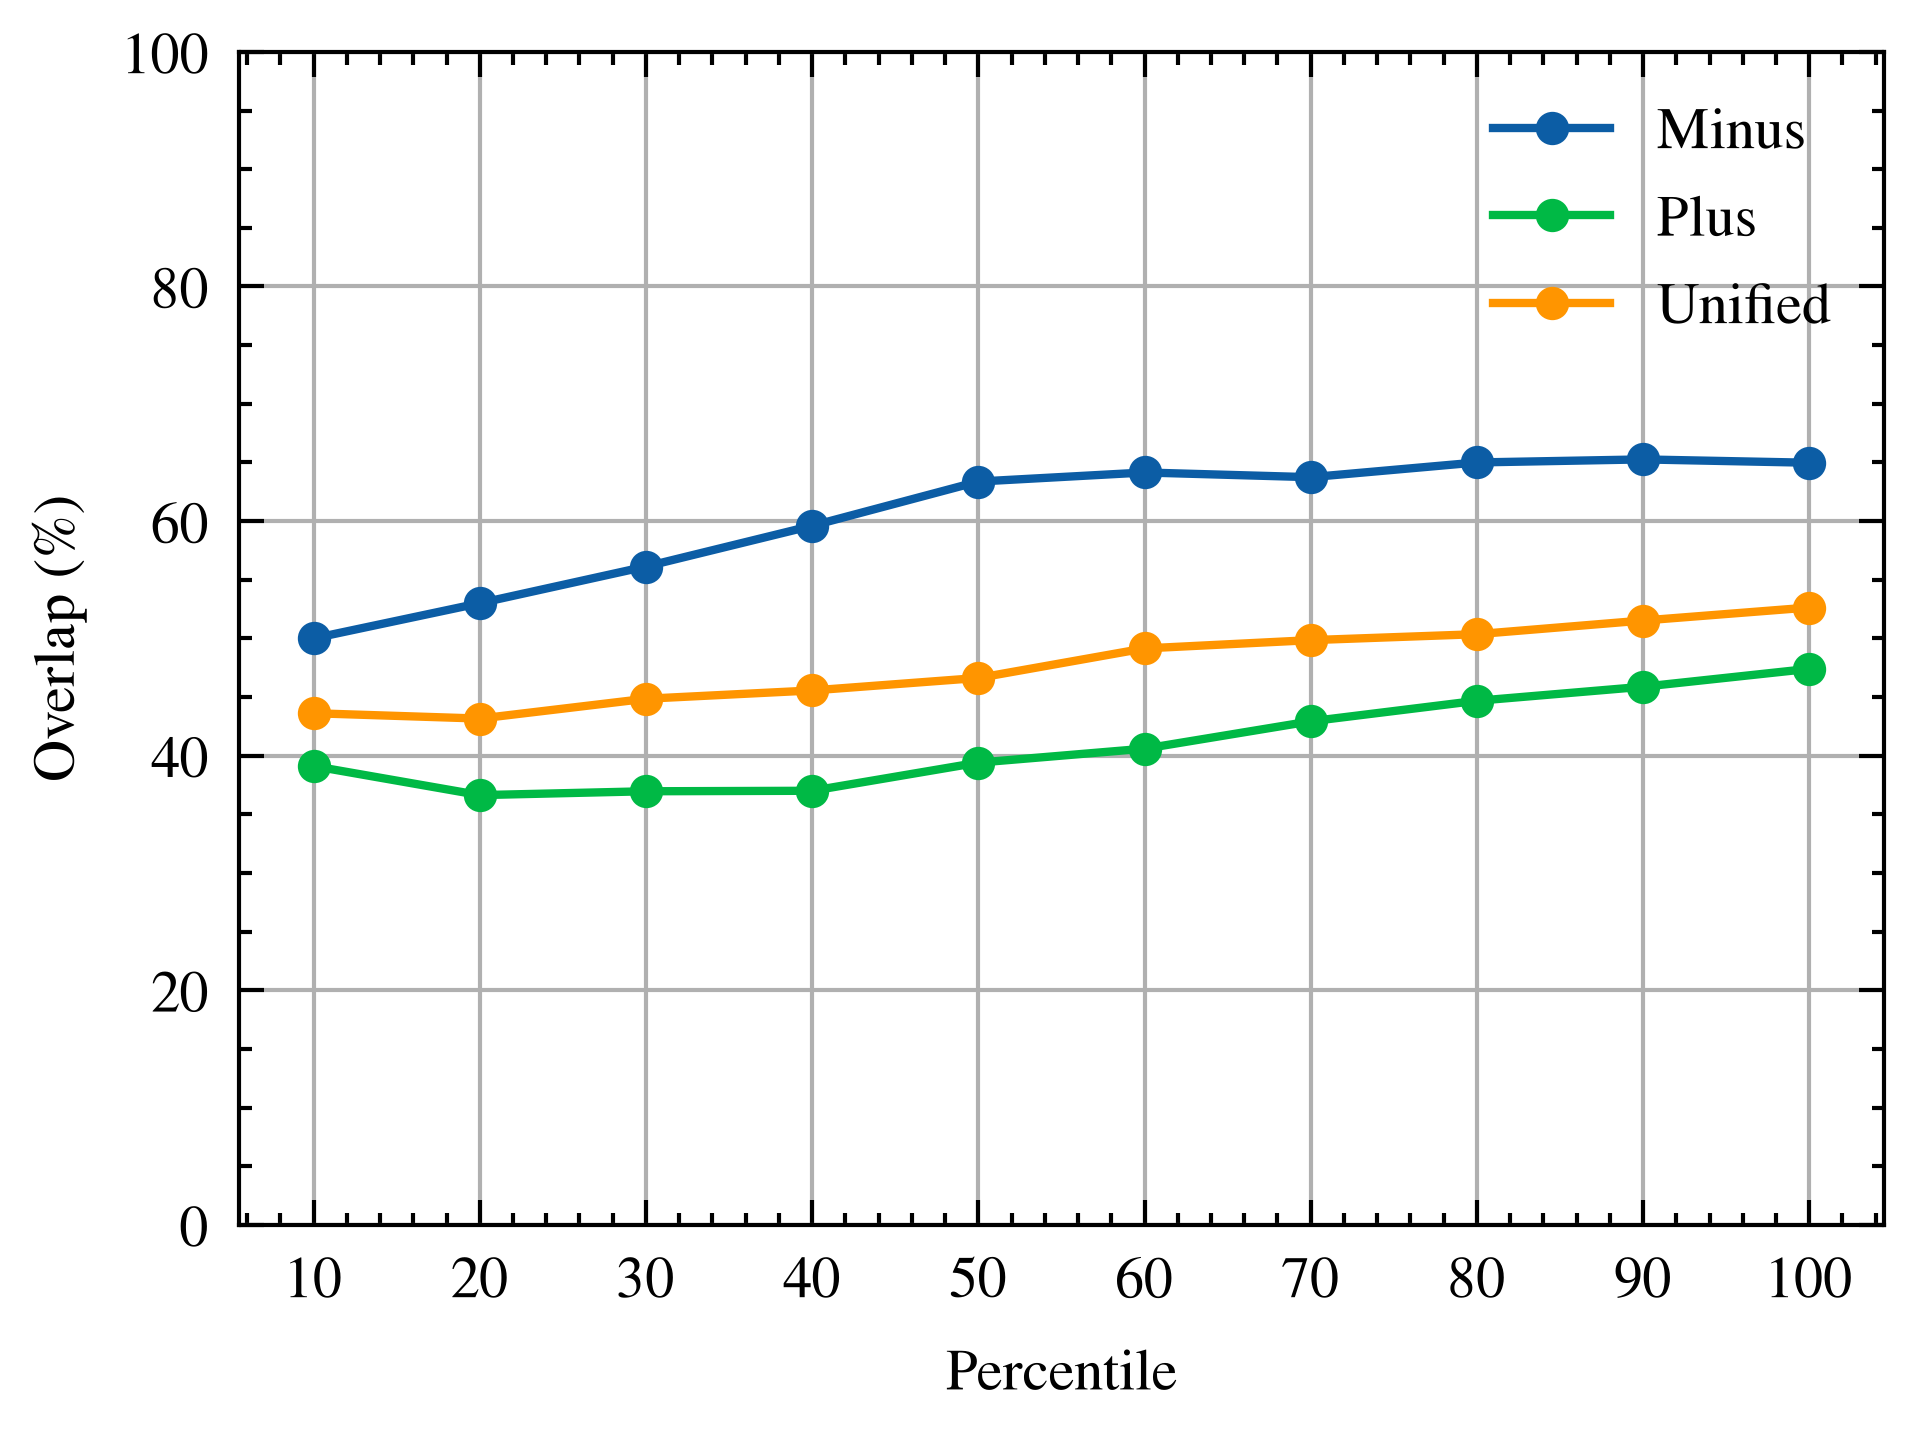

In [174]:
plt.figure()
plt.plot(percentiles, 100 * num_overlap_minus / num_genes_minus, marker="o", label="Minus")
plt.plot(percentiles, 100 *num_overlap_plus / num_genes_plus, marker="o", label="Plus")
plt.plot(percentiles, 100 * num_overlap_unified / num_genes_unified, marker="o", label="Unified")

plt.xlabel("Percentile")
plt.ylabel("Overlap (%)")
plt.xticks(percentiles)
plt.ylim(0, 100)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [175]:
exclusive_to_CASh_plus, exclusive_to_DEG_plus, common_plus = mutually_exclusive_sets(df_CASh_plus, df_DEG_plus)
exclusive_to_CASh_minus, exclusive_to_DEG_minus, common_minus = mutually_exclusive_sets(df_CASh_minus, df_DEG_minus)
exclusive_to_CASh_unified, exclusive_to_DEG_unified, common_unified = mutually_exclusive_sets(df_CASh_unified, df_DEG_unified)

## Enrichment Analysis

In [176]:
gene_sets = {
    "plus": {
        "exclusive_to_CASh": exclusive_to_CASh_plus,
        "exclusive_to_DEG": exclusive_to_DEG_plus,
        "common": common_plus
    },
    "minus": {
        "exclusive_to_CASh": exclusive_to_CASh_minus,
        "exclusive_to_DEG": exclusive_to_DEG_minus,
        "common": common_minus
    },
    "unified": {
        "exclusive_to_CASh": exclusive_to_CASh_plus.union(exclusive_to_CASh_minus),
        "exclusive_to_DEG": exclusive_to_DEG_plus.union(exclusive_to_DEG_minus),
        "common": common_plus.union(common_minus)
    }
}

In [177]:
background = df_expression.index.tolist()

libraries = [
    'KEGG_2021_Human', 
    'Reactome_2022',
    'MSigDB_Hallmark_2020', 
    'GO_Biological_Process_2023'
]

# 2. Download/load the libraries locally to map the exact pathway sizes
all_pathways = {}
for lib in libraries:
    # This fetches a dictionary of { 'Pathway_Name': ['Gene1', 'Gene2', ...] }
    lib_dict = gp.get_library(name=lib, organism='human')
    all_pathways.update(lib_dict)

# 3. Function to construct the background-aware "Numerator/Denominator" string
def create_overlap_string(row):
    term = row['Term']
    
    # Calculate Numerator (your genes that hit the pathway)
    if pd.notna(row['Genes']) and str(row['Genes']).strip() != "":
        genes_hit = str(row['Genes']).split(';')
        num_hits = len(genes_hit)
    else:
        genes_hit = []
        num_hits = 0
    
    # Calculate Denominator (pathway genes restricted to your exact dataset)
    if term in all_pathways:
        pathway_genes = set(str(g).strip() for g in all_pathways[term])
        # Find how many pathway genes actually exist in your dataset
        effective_pathway_size = len(pathway_genes.intersection(background))
        
        # Failsafe in case a pathway somehow has fewer background genes than hits 
        # (usually due to alias/synonym mapping differences between tools)
        effective_pathway_size = max(effective_pathway_size, num_hits)
    else:
        # Fallback if term is missing from local dict
        effective_pathway_size = num_hits
        
    return f"{num_hits}/{effective_pathway_size}"

In [178]:
for direction, gene_sets_dict in gene_sets.items():
    for df_name, df in gene_sets_dict.items():
        if len(df) == 0:
            print(f"No genes in {df_name}, skipping enrichment.")
            continue

        # Perform enrichment analysis for each gene set
        output_dir = RESULT_DIR / DATASET / RUN / COMPARISON / direction / "gsea" / df_name
        output_dir.mkdir(exist_ok=True, parents=True)
        enr = gp.enrichr(
            gene_list=list(df),
            gene_sets=libraries,
            background=background,  # Use the full expression dataset as background
            outdir=None,  # No output files generated by gseapy
            cutoff=0.05  # Only significant terms
        )

        # Add the background-aware overlap string to the results
        if enr.res2d is not None and not enr.res2d.empty:
            enr.res2d['Overlap'] = enr.res2d.apply(create_overlap_string, axis=1)
            print(f"Enrichment results for {df_name} {direction}:")
            display(enr.res2d[['Term', 'Adjusted P-value', 'Combined Score', 'Overlap']])
        else:
            print(f"No significant enrichment found for {df_name} {direction}.")

        enr.res2d.to_csv(output_dir / "enrichment_results.csv", index=False)

        # Dotplot
        fig = gp.dotplot(
            enr.res2d,
            column="Adjusted P-value",
            x='Gene_set',          # split the x-axis by library (multi-library comparison)
            size=5,
            top_term=5,
            xticklabels_rot=45,    # rotate x tick labels for readability
            show_ring=False,        # set False to remove the outer ring around dots
            marker='o',
        )
        fig.figure.savefig(output_dir / "dotplot.pdf", dpi=300, bbox_inches="tight")
        plt.close(fig.figure)

        # Dotplot 2
        fig = gp.dotplot(enr.res2d, cmap='viridis', size=5)
        fig.figure.savefig(output_dir / "dotplot2.pdf", dpi=300, bbox_inches="tight")
        plt.close(fig.figure)

        # Barplot
        fig = gp.barplot(
            enr.res2d,
            column="Adjusted P-value",
            group='Gene_set',      # group bars by library (multi-library comparison)
            size=5,
            top_term=5,
            color={'KEGG_2021_Human': 'salmon', 'GO_Biological_Process_2023': 'darkblue', 'MSigDB_Hallmark_2020': 'lightgreen', 'Reactome_2022': 'orange'}
        )
        fig.figure.savefig(output_dir / "barplot.pdf", dpi=300, bbox_inches="tight")
        plt.close(fig.figure)

Enrichment results for exclusive_to_CASh plus:


,Term,Adjusted P-value,Combined Score,Overlap
0,RNA transport,9.541986e-16,248.138280,44/161
1,Spliceosome,1.841736e-14,238.805109,38/133
2,Ribosome biogenesis in eukaryotes,2.302153e-08,144.989039,22/76
3,DNA replication,3.718067e-05,115.038437,12/36
4,Proteasome,2.477866e-04,75.874038,12/43
...,...,...,...,...
4078,Transmembrane Receptor Protein Tyrosine Kinase...,9.999890e-01,0.000015,4/271
4079,Chemical Synaptic Transmission (GO:0007268),9.999890e-01,0.000008,3/247
4080,Regulation Of ERK1 And ERK2 Cascade (GO:0070372),9.999890e-01,0.000002,2/229
4081,Cytokine-Mediated Signaling Pathway (GO:0019221),9.999890e-01,0.000002,2/232


Enrichment results for exclusive_to_DEG plus:


,Term,Adjusted P-value,Combined Score,Overlap
0,Cytokine-cytokine receptor interaction,0.000129,3.965263e+01,37/257
1,Neuroactive ligand-receptor interaction,0.000241,3.338077e+01,38/282
2,Salivary secretion,0.002970,3.830814e+01,16/85
3,Staphylococcus aureus infection,0.004734,3.476982e+01,15/81
4,Protein digestion and absorption,0.013230,2.531592e+01,16/100
...,...,...,...,...
4228,Ubiquitin-Dependent Protein Catabolic Process ...,0.999995,6.884415e-06,6/351
4229,Protein Stabilization (GO:0050821),0.999995,1.217107e-06,1/185
4230,Protein Transport (GO:0015031),0.999995,8.517381e-07,3/304
4231,Vesicle-Mediated Transport (GO:0016192),0.999995,1.009611e-06,5/390


Enrichment results for common plus:


...

,Term,Adjusted P-value,Combined Score,Overlap
0,RNA transport,1.110886e-10,120.558931,46/161
1,Spliceosome,3.124262e-10,121.501265,40/133
2,Ribosome biogenesis in eukaryotes,3.933930e-05,62.516713,22/76
3,DNA replication,2.755851e-03,52.871902,12/36
4,RNA degradation,1.005796e-02,27.359689,17/73
...,...,...,...,...
5374,Inflammatory Response (GO:0006954),9.999739e-01,0.000224,8/223
5375,Cell-Matrix Adhesion (GO:0007160),9.999739e-01,0.000108,2/107
5376,Regulation Of Peptidyl-Tyrosine Phosphorylatio...,9.999739e-01,0.000034,1/88
5377,Enzyme-Linked Receptor Protein Signaling Pathw...,9.999739e-01,0.000032,2/120


Enrichment results for exclusive_to_DEG unified:


,Term,Adjusted P-value,Combined Score,Overlap
0,Bile secretion,8.522886e-08,1.146011e+02,28/84
1,Protein digestion and absorption,8.076772e-07,8.104030e+01,29/100
2,Ascorbate and aldarate metabolism,8.346920e-07,2.045352e+02,14/27
3,Cytokine-cytokine receptor interaction,8.346920e-07,4.872542e+01,52/257
4,Fat digestion and absorption,1.276345e-06,1.297517e+02,17/41
...,...,...,...,...
5028,RNA Processing (GO:0006396),9.999958e-01,6.460907e-07,2/174
5029,Vesicle-Mediated Transport (GO:0016192),9.999958e-01,1.530527e-06,11/390
5030,Ubiquitin-Dependent Protein Catabolic Process ...,9.999958e-01,1.134978e-06,8/351
5031,Mitochondrion Organization (GO:0007005),9.999958e-01,3.300508e-07,1/147


Enrichment results for common unified:


,Term,Adjusted P-value,Combined Score,Overlap
0,Neuroactive ligand-receptor interaction,5.261682e-11,8.898833e+01,74/282
1,Nicotine addiction,4.639669e-04,7.812698e+01,14/33
2,cAMP signaling pathway,5.179101e-03,2.019473e+01,41/205
3,Mineral absorption,5.179101e-03,3.406227e+01,17/57
4,Glutamatergic synapse,5.181044e-03,2.427752e+01,26/110
...,...,...,...,...
5825,Mitochondrial Translation (GO:0032543),9.999958e-01,1.606760e-06,1/97
5826,Golgi Organization (GO:0007030),9.999958e-01,1.831814e-06,2/125
5827,Ubiquitin-Dependent Protein Catabolic Process ...,9.999958e-01,1.645610e-06,13/351
5828,Proteasome-Mediated Ubiquitin-Dependent Protei...,9.999958e-01,1.432351e-06,10/303
